# Swiggy Bangalore Restaurant Analysis — Exploratory Data Analysis (EDA)

## Objective:
- This notebook analyzes restaurant listings scraped from Swiggy for Bangalore to understand pricing, ratings, and cuisine trends across the city's key dining hubs. Specifically, it answers:- How do ratings and cost-for-two vary across Bangalore's major food hubs (BTM, HSR, Koramangala)?
- Is there a relationship between cost and rating -- do more expensive restaurants get rated higher?
- Which restaurants offer the best value (high rating, low cost)?
- Which cuisines are most common overall, and does that vary by area?


## Dataset:
- **Source:** `Swiggy Bangalore Outlet Details.csv` (scraped restaurant listings)
- **Size:** 118 restaurants × 5 columns
- **Key columns:** `Shop_Name`, `Cuisine`, `Location`, `Rating`, `Cost_for_Two`


## Tools Used`pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly.express`


## Approach:
- 1. Clean the raw data (handle rating placeholders, currency-formatted costs, and location text)
- 2. Segment restaurants into three key Bangalore dining hubs: BTM, HSR, and Koramangala.
- 3. Analyze rating and cost distribution, both city-wide and per area.
- 4. Identify the best value restaurants (affordable + highly rated)
- 5. Analyze cuisine popularity, both city-wide and per area
- 6. Summarize key findings and recommendations at the end

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly. express as px

In [57]:
df_Swiggy = pd.read_csv('Swiggy Bangalore Outlet Details.csv')
df_Swiggy.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,₹ 150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,₹ 400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,₹ 126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,₹ 400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,₹ 450


In [58]:
# how many features are there in datasets
df_Swiggy.columns

Index(['Shop_Name', 'Cuisine', 'Location', 'Rating', 'Cost_for_Two'], dtype='object')

In [59]:
# Check for missinng value  in datasets
df_Swiggy.isnull().sum()  #

Shop_Name       0
Cuisine         0
Location        0
Rating          0
Cost_for_Two    0
dtype: int64

In [60]:
df_Swiggy.info()   # Logical structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Shop_Name     118 non-null    object
 1   Cuisine       118 non-null    object
 2   Location      118 non-null    object
 3   Rating        118 non-null    object
 4   Cost_for_Two  118 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


## Data Pre-Processing & Cleaning

In [61]:
df_Swiggy.duplicated().sum() # To Check if  there is idenntical rows.

np.int64(0)

In [62]:
# how many different ratings are in dataset
df_Swiggy['Rating'].unique()

array(['4.3', '4.4', '4.1', '4.2', '3.9', '3.8', '4', '3.7', '3.6', '4.8',
       '4.5', '4.6', '--'], dtype=object)

In [63]:
# Replace '--' rating with zero(0)
df_Swiggy['Rating'] = df_Swiggy['Rating'].str.replace('--','0').astype(float)


In [64]:
df_Swiggy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Shop_Name     118 non-null    object 
 1   Cuisine       118 non-null    object 
 2   Location      118 non-null    object 
 3   Rating        118 non-null    float64
 4   Cost_for_Two  118 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.7+ KB


In [65]:
# How many unique entries for 'Cost_for_Two' feature
df_Swiggy['Cost_for_Two' ].unique()

array(['₹ 150', '₹ 400', '₹ 126', '₹ 450', '₹ 350', '₹ 200', '₹ 500',
       '₹ 247', '₹ 550', '₹ 300', '₹ 129', '₹ 250', '₹ 268', '₹ 600',
       '₹ 527', '₹ 130', '₹ 257', '₹ 280', '₹ 399', '₹ 220', '₹ 800',
       '₹ 100', '₹ 178', '₹ 120', '₹ 251', '₹ 650', '₹ 132', '₹ 153',
       '₹ 219', '₹ 193'], dtype=object)

In [66]:
df_Swiggy['Cost_for_Two'] = df_Swiggy['Cost_for_Two'].str.replace("₹ ","").astype(int)

In [67]:
df_Swiggy['Cost_for_Two'].unique()

array([150, 400, 126, 450, 350, 200, 500, 247, 550, 300, 129, 250, 268,
       600, 527, 130, 257, 280, 399, 220, 800, 100, 178, 120, 251, 650,
       132, 153, 219, 193])

In [68]:
# Handling Feature --------> Location 
df_Swiggy['Location'].unique()

array(['Koramangala, Koramangala', 'Sector 5, HSR',
       '6th Block, Koramangala', 'HSR, HSR', '5th Block, Koramangala',
       'Koramangala 4th  Block, Koramangala', 'BTM 2nd Stage, BTM',
       'BTM, BTM', '9th Main road, Koramangala', 'outer ring road, BTM',
       '7th Block, Koramangala', '1st MAin, Koramangala',
       'Bommanahalli, BTM', '6th block, Koramangala', 'Sector 4, HSR',
       'BTM 1st stage, BTM', 'Jakkasandra Extn, Koramangala',
       'Marutinagar Main Road, BTM', '1st Block, Koramangala',
       '4th Cross, BTM', 'koramangala, Koramangala', 'BTM 2nd stage, BTM',
       '3rd main, BTM', 'HSR 1st sector, HSR', 'Sector 7, HSR',
       '3rd Sector, HSR', 'Chocolate Factory Road, BTM',
       '16th Main Road, 2nd Stage, BTM', '1st Stage, BTM',
       'Hosur Main Road, Koramangala',
       '1st Cross Road, 5th Block, Near Jyothi Nivas College, Koramangala',
       'Mico Layout, BTM', '4th Cross, Koramangala',
       '4th Block, Koramangala', 'Intermediate Ring Road, K

In [69]:
# Locations that contain Koramangalam
swiggy_Koramangala = df_Swiggy[df_Swiggy['Location'].str.contains('Koramangala')]
swiggy_Koramangala

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
5,Kitchens of Punjab,North Indian,"Koramangala 4th Block, Koramangala",4.2,350
9,Yumlane Pizza,"Pizzas, Italian, Mexican","9th Main road, Koramangala",3.8,150
...,...,...,...,...,...
112,Kritunga,"Andhra, Biryani","5th Block, Koramangala",3.9,500
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [70]:
# Locations that containn HSR
swiggy_HSR = df_Swiggy[df_Swiggy['Location'].str.contains('HSR')]
swiggy_HSR

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
8,Hotel Manu,"South Indian, Kerala, Chinese, North Indian","HSR, HSR",4.1,350
19,Shree Khana Khazana,"Indian, Rajasthani","Sector 4, HSR",4.1,350
24,New Udupi Grand,"Chinese, Jain, North Indian, South Indian","HSR, HSR",4.3,150
36,Biriyani Zone,"North Indian, Chinese, Biryani","HSR 1st sector, HSR",4.1,600
37,Gongura's,"North Indian, Chinese, Biryani","Sector 7, HSR",3.8,300
39,Leon Grill,"Turkish, Portuguese, American","3rd Sector, HSR",4.3,300
41,Cakewala,Desserts,"HSR, HSR",4.3,450
57,Donne Biriyani House,South Indian,"3rd sector, HSR",4.0,300


In [71]:
# Locations that contain BTM
swiggy_BTM = df_Swiggy[df_Swiggy['Location'].str.contains('BTM')]
swiggy_BTM

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
6,99 VARIETY DOSA AND PAV BHAJI- Malli Mane Food...,"Fast Food, North Indian, Chinese","BTM 2nd Stage, BTM",4.1,200
7,La Pino'z Pizza,Italian,"BTM, BTM",3.9,500
10,Ambur Star Briyani,"Chinese, South Indian, North Indian, Desserts,...","outer ring road, BTM",4.1,500
17,Sri Lakshmi Dhaba,North Indian,"Bommanahalli, BTM",3.7,200
20,Just Bake - Cakes & confectioners,"Desserts, Bakery","BTM 1st stage, BTM",4.3,300
22,Hotel Godavari,"North Indian, Chinese, Hyderabadi","Marutinagar Main Road, BTM",4.0,400
25,Swad Punjab da,Indian,"BTM, BTM",4.1,250
27,High N Hungry,"Andhra, Biryani, Chinese, Desserts, Fast Food,...","4th Cross, BTM",4.1,350
31,Bengali Fun Foods,North Indian,"BTM 2nd stage, BTM",4.2,300
33,Oottupura,"Kerala, South Indian","BTM, BTM",4.3,268


### Data Cleaning Summary:
The raw dataset contains **118 restaurant listings** across 5 columns (`Shop_Name`, `Cuisine`, `Location`, `Rating`, `Cost_for_Two`), scraped from Swiggy for Bangalore. No missing values and no duplicate rows were found. 
The following cleaning steps were applied:- **`Rating`**: placeholder values of `'--'` (restaurants with no rating yet) were replaced with `0` and the column was converted from text to `float`.- **`Cost_for_Two`**: the currency symbol (`₹`) was stripped from each value and the column was converted to `int`.- **`Location`**: the free-text location strings were parsed to identify three key Bangalore dining hubs -- **Koramangala, HSR, and BTM** -- by matching on substrings, creating dedicated subsets (`swiggy_Koramangala`, `swiggy_HSR`, `swiggy_BTM`) for area-wise comparison. 

**Note:** unrated restaurants were encoded as a `Rating` of `0` rather than left as null. This is worth keeping in mind for any rating-based analysis (e.g. histograms, averages), since a `0` will be treated as a genuine low rating rather than "no rating available."

## Area-Wise Analysis

### 1. BTM Area

<Axes: xlabel='Rating', ylabel='Count'>

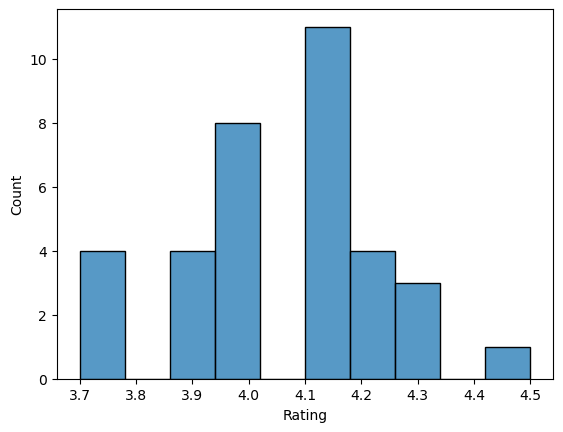

In [72]:
sns.histplot(swiggy_BTM['Rating'], bins = 10)

**Insight:** BTM ratings cluster tightly in a narrow band — the 4.1–4.2 range alone accounts for 11 restaurants, the single largest group, with another 8 restaurants at 4.0. Together, ratings between 4.0 and 4.3 cover the vast majority of BTM restaurants (11 + 8 + 4 + 3 = 26 of the area's listings), while only a handful fall below 4.0 (4 at 3.7, 4 at 3.9) or above 4.3 (just 1 at 4.5). This tight clustering suggests BTM has a fairly consistent baseline of restaurant quality, with very few outliers on either end — no restaurant in this sample is rated below 3.7 or above 4.5.

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

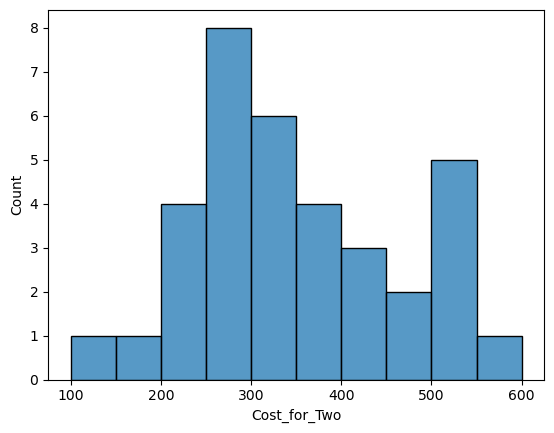

In [73]:
sns.histplot(swiggy_BTM['Cost_for_Two'], bins = 10)

**Insight:** Most BTM restaurants are rated between **4.0 and 4.2**, and the typical cost for two is **₹200-350** -- positioning BTM as a solid, affordably-priced dining cluster.

### 2. HSR Area

<Axes: xlabel='Rating', ylabel='Count'>

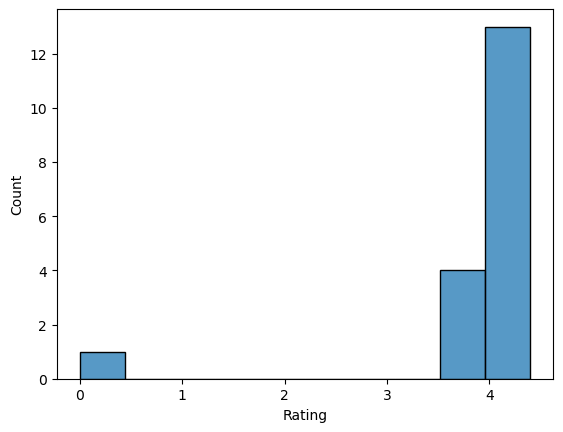

In [74]:
sns.histplot(swiggy_HSR['Rating'], bins = 10)

**Insight**: HSR ratings are tightly concentrated near the top — 13 restaurants rated ~4.0–4.4, another 4 just below. One restaurant shows as 0, which is the placeholder for unrated listings, not a real 1-star review — should be excluded before calculating HSR's average rating.

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

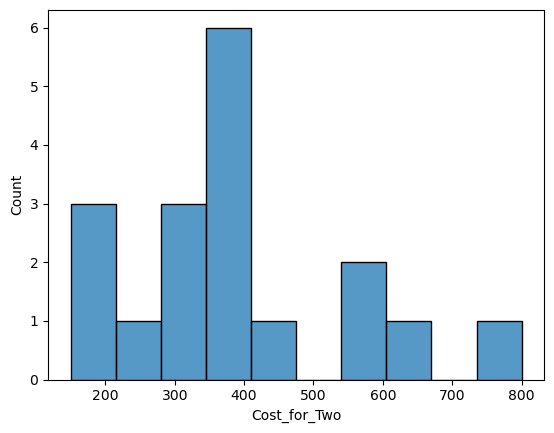

In [75]:
sns.histplot(swiggy_HSR['Cost_for_Two'], bins = 10)

**Insight:** HSR restaurants mostly carry ratings of **4.0 and above**, with cost for two typically between **₹300-400** (a handful running as high as ₹800) -- HSR skews slightly pricier than BTM while maintaining similarly strong ratings.

### 3. Koramangala Area

<Axes: xlabel='Rating', ylabel='Count'>

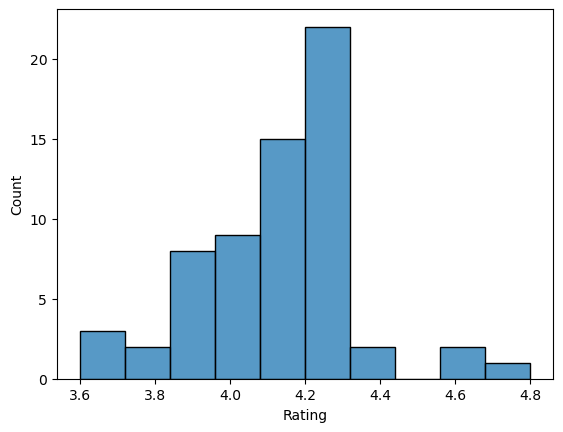

In [76]:
sns.histplot(swiggy_Koramangala['Rating'], bins = 10)

**Insight**: Koramangala peaks sharply at 4.1–4.2 (22 restaurants), with a strong build-up from 4.0 (9) and 4.1 (15) leading into it — Bangalore's largest, most food-dense hub also has its most tightly clustered, consistently high ratings. A small tail extends up to 4.6–4.8 (3 restaurants), with very few below 3.8.


<Axes: xlabel='Cost_for_Two', ylabel='Count'>

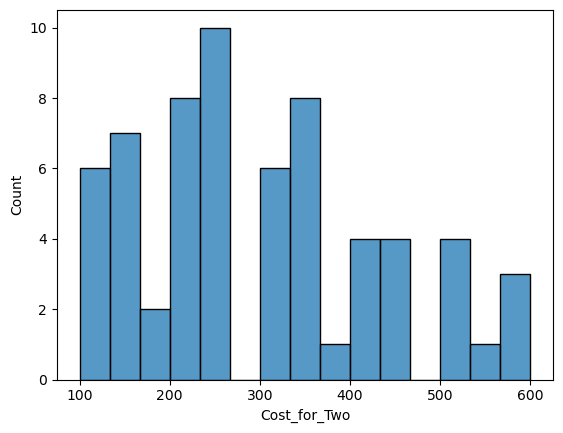

In [77]:
sns.histplot(swiggy_Koramangala['Cost_for_Two'], bins = 15)

**Insight:** Koramangala restaurants mostly rate between **4.1 and 4.3**, with cost for two typically **₹200-350** -- very close to BTM's price range, suggesting Koramangala offers comparable value with marginally higher average ratings.

In [78]:
df_Highest_Rated_Restaurants = df_Swiggy[df_Swiggy["Rating"] >= 4.0]
df_Highest_Rated_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [79]:
df_Highest_Rated_Restaurants = df_Highest_Rated_Restaurants.loc[:, ["Shop_Name", "Rating", "Cost_for_Two"]]
df_Highest_Rated_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
111,Bowl 99,4.4,200
114,Savoury Restaurant,4.1,600
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


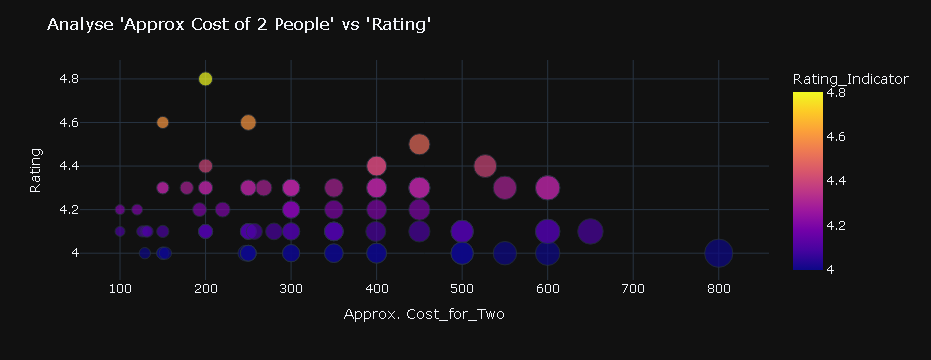

In [80]:
fig = px.scatter(
    x=df_Highest_Rated_Restaurants["Cost_for_Two"],
    y=df_Highest_Rated_Restaurants["Rating"],
    color = df_Highest_Rated_Restaurants["Rating"],
    size = df_Highest_Rated_Restaurants["Cost_for_Two"],
    labels={
        "x": "Approx. Cost_for_Two",
        "y": "Rating",
        "color": "Rating_Indicator"
        
    }
)
fig.update_layout(
    template="plotly_dark",
    title = "Analyse 'Approx Cost of 2 People' vs 'Rating'"
)
fig.show()

**Insight:** The scatter plot shows no strong linear relationship between cost and rating -- highly rated restaurants (4.0+) are found across almost the entire price range, from budget options under ₹200 to premium spots above ₹600. In other words, **a higher price does not reliably predict a better rating** on this dataset, which is useful context for the affordability analysis below.

## Cost vs. Rating Analysis

**Insight:** Filtering for restaurants that are both **affordable (cost for two ≤ ₹500)** and **highly rated (rating ≥ 4.0)** surfaces a strong list of value-for-money options -- proof that budget-friendly dining in Bangalore doesn't require sacrificing quality.

In [81]:
# Analyzing Affordable/Budgeted and Highest Rated Restaurants of Bangalore:
df_Affordable_Restaurants = df_Swiggy[(df_Swiggy["Cost_for_Two"] <= 500) & (df_Swiggy["Rating"] >= 4.0)]
df_Affordable_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
110,Biryani Pot,"North Indian, Biryani","Madiwala Junction, BTM",4.0,500
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [82]:
df_Affordable_Restaurants = df_Affordable_Restaurants.loc[:, ["Shop_Name", "Rating", "Cost_for_Two"]]
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
110,Biryani Pot,4.0,500
111,Bowl 99,4.4,200
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [83]:
df_Affordable_Restaurants.sort_values(by='Rating', ascending=False, inplace=True)
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
78,Khichdi Experiment,4.8,200
82,Natural Ice Cream,4.6,150
94,Corner House Ice Cream,4.6,250
80,Chinese Bae,4.5,450
3,Al Daaz,4.4,400
...,...,...,...
21,Maa Di Hatti,4.0,129
58,Nanda's,4.0,400
57,Donne Biriyani House,4.0,300
22,Hotel Godavari,4.0,400


C:\Users\krish\AppData\Local\Temp\ipykernel_25656\3745283813.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




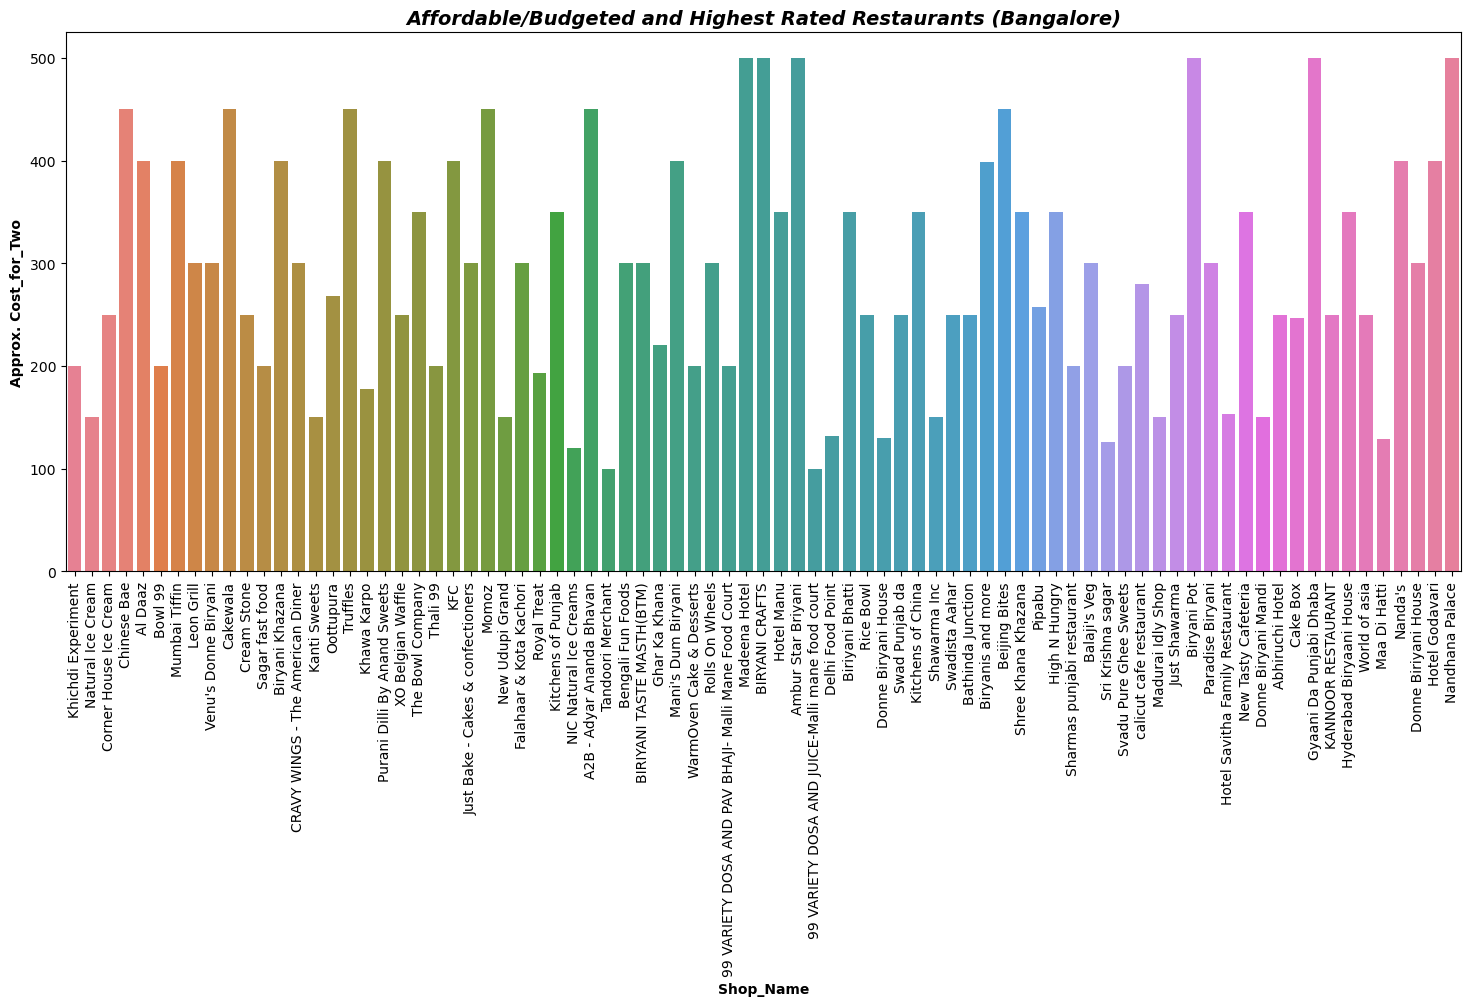

In [84]:
plt.figure(figsize=(18, 7))
sns.barplot(x="Shop_Name",y="Cost_for_Two",data=df_Affordable_Restaurants, palette="husl")
plt.title(
    "Affordable/Budgeted and Highest Rated Restaurants (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic"
)
plt.xlabel("Shop_Name", fontsize=10, fontweight="bold")
plt.ylabel("Approx. Cost_for_Two", fontsize=10, fontweight="bold")
plt.xticks(rotation=90)
plt.show()

**Insight:** Among affordable, highly-rated restaurants, **Khichdi Experiment (4.8, ₹200)**, **Natural Ice Cream (4.6, ₹150)**, and **Corner House Ice Cream (4.6, ₹250)** top the list -- all well under the ₹500 threshold, showing that some of the best-reviewed spots in the dataset are also among the cheapest.

In [85]:
# Top 15 chaeapest and highest  rated restaurants with approx. cost  of 2 people:
df_Cheapest_Restaurants = df_Affordable_Restaurants.sort_values(by="Cost_for_Two", ascending= True)
df_Cheapest_Restaurants

,Shop_Name,Rating,Cost_for_Two
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100
79,Tandoori Merchant,4.2,100
95,NIC Natural Ice Creams,4.2,120
2,Sri Krishna sagar,4.1,126
21,Maa Di Hatti,4.0,129
...,...,...,...
110,Biryani Pot,4.0,500
10,Ambur Star Briyani,4.1,500
92,BIRYANI CRAFTS,4.1,500
86,Gyaani Da Punjabi Dhaba,4.0,500


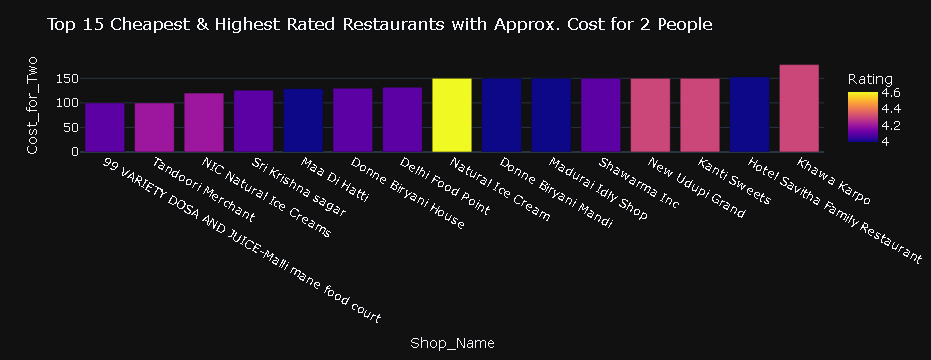

In [86]:
# import plotly.express as px
fig = px.bar(
    data_frame = df_Cheapest_Restaurants.head(15),
    x = df_Cheapest_Restaurants["Shop_Name"][0:15],
    y = df_Cheapest_Restaurants["Cost_for_Two"][0:15],
    color = df_Cheapest_Restaurants["Rating"][0:15],
    labels ={
        "x": "Restaurants_Name",
        "y": "Approx. Cost_for_Two",
        "color": "Rating",
    }
)
fig.update_layout(
    template="plotly_dark",
    title="Top 15 Cheapest & Highest Rated Restaurants with Approx. Cost for 2 People",
)

fig.show()

**Insight:** The cheapest restaurants that still maintain a 4.0+ rating include **99 Variety Dosa and Juice (4.1, ₹100)**, **Tandoori Merchant (4.2, ₹100)**, and **NIC Natural Ice Creams (4.2, ₹120)** -- all at or near the ₹100 mark, making them the best value options in the entire dataset.

In [87]:
# Top 15 Expensive & Highest Rated Restaurants with Approx. Cost for 2 People:
df_Expensive_Restaurants = df_Highest_Rated_Restaurants.sort_values(by="Cost_for_Two", ascending=False)
df_Expensive_Restaurants

,Shop_Name,Rating,Cost_for_Two
73,Punjabi Rasoi,4.0,800
99,Dindigul Thalapakatti Biriyani,4.1,650
36,Biriyani Zone,4.1,600
72,Nagarjuna,4.3,600
34,Taco Bell,4.3,600
...,...,...,...
21,Maa Di Hatti,4.0,129
2,Sri Krishna sagar,4.1,126
95,NIC Natural Ice Creams,4.2,120
79,Tandoori Merchant,4.2,100


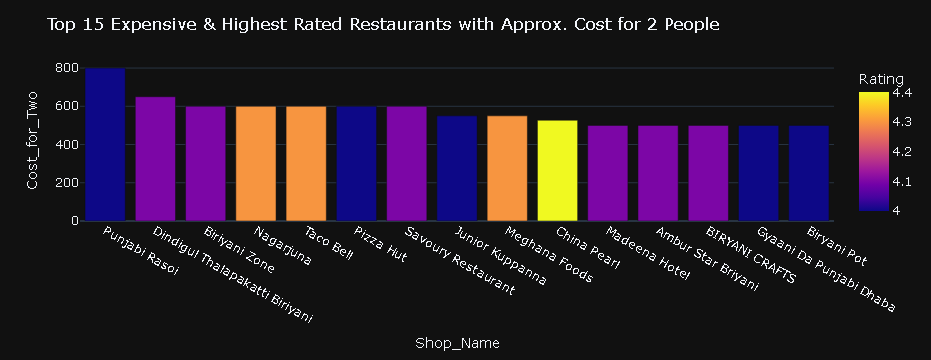

In [88]:
fig = px.bar(
    data_frame=df_Expensive_Restaurants.head(15),
    x=df_Expensive_Restaurants["Shop_Name"][0:15],
    y=df_Expensive_Restaurants["Cost_for_Two"][0:15],
    color=df_Expensive_Restaurants["Rating"][0:15],
    labels={
        "x": "Restaurant_Name",
        "y": "Approx. Cost_for_Two",
        "color": "Rating",
    }

)
fig.update_layout(
template="plotly_dark",
title="Top 15 Expensive & Highest Rated Restaurants with Approx. Cost for 2 People",
)
fig.show()

**Insight:** At the premium end, **Punjabi Rasoi (4.0, ₹800)** is the single most expensive highly-rated restaurant, followed by **Dindigul Thalapakatti Biriyani (4.1, ₹650)** and **Biriyani Zone (4.1, ₹600)**. Notably, their ratings (4.0-4.3) aren't meaningfully higher than the ₹100-200 options above -- reinforcing that price is a weak predictor of rating on Swiggy in Bangalore.

## Cuisine Analysis

In [89]:
df_Swiggy["Cuisine"]= df_Swiggy["Cuisine"].str.title()
df_Swiggy["Cuisine"]

0                                                 Sweets
1                 North Indian, Home Food, Thalis, Combo
2      South Indian, North Indian, Fast Food, Beverag...
3      American, Arabian, Chinese, Desserts, Fast Foo...
4                                          Chinese, Thai
                             ...                        
113                            Pan-Asian, Chinese, Asian
114    Arabian, Middle Eastern, North Indian, Grill, ...
115              North Indian, Chinese, Seafood, Biryani
116                                         North Indian
117                                      Andhra, Biryani
Name: Cuisine, Length: 118, dtype: object

In [90]:
# LOGIC BUILDING:
# x={}
#  for i in range(10):
#     name=input("enter the name")
#     if name in x:
#         x[name ]=x[name]+1 
#      else:
#         x[name ]=1
#         print(x)

In [91]:
freq_dict = {}
for i in df_Swiggy["Cuisine"].unique():
     Cuisines_Lists = i.split(",") #words list
     for Cuisine in Cuisines_Lists:
         Cuisine = Cuisine.lstrip(" ") #removed left space
         if Cuisine in freq_dict:
             freq_dict[Cuisine] = freq_dict[Cuisine] + 1
         else:
             freq_dict[Cuisine] = 1
print(freq_dict)
print()
print("Total Records: ", len(freq_dict))

{'Sweets': 2, 'North Indian': 32, 'Home Food': 2, 'Thalis': 1, 'Combo': 1, 'South Indian': 23, 'Fast Food': 16, 'Beverages': 9, 'Jain': 2, 'American': 8, 'Arabian': 4, 'Chinese': 35, 'Desserts': 15, 'Mughlai': 7, 'Thai': 2, 'Italian': 4, 'Kerala': 6, 'Pizzas': 5, 'Mexican': 3, 'Andhra': 12, 'Seafood': 8, 'Biryani': 18, 'Indian': 5, 'Rajasthani': 1, 'Bakery': 2, 'Healthy Food': 4, 'Hyderabadi': 5, 'Snacks': 4, 'Turkish': 2, 'Portuguese': 2, 'Chaat': 2, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 2, 'Juices': 2, 'Kebabs': 2, 'Grill': 2, 'Ice Cream': 2, 'Tandoor': 1, 'Chettinad': 2, 'Pan-Asian': 2, 'Oriental': 1, 'Middle Eastern': 1}

Total Records:  48


In [92]:
# Extracting Cuisines name and there frequency:
Cuisine = freq_dict.keys()
freq = freq_dict.values()

df_Cuisine_Analysis = pd.DataFrame({"Cuisine":Cuisine, "Count":freq})

df_Cuisine_Analysis

,Cuisine,Count
0,Sweets,2
1,North Indian,32
2,Home Food,2
3,Thalis,1
4,Combo,1
5,South Indian,23
6,Fast Food,16
7,Beverages,9
8,Jain,2
9,American,8


C:\Users\krish\AppData\Local\Temp\ipykernel_25656\4126944218.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




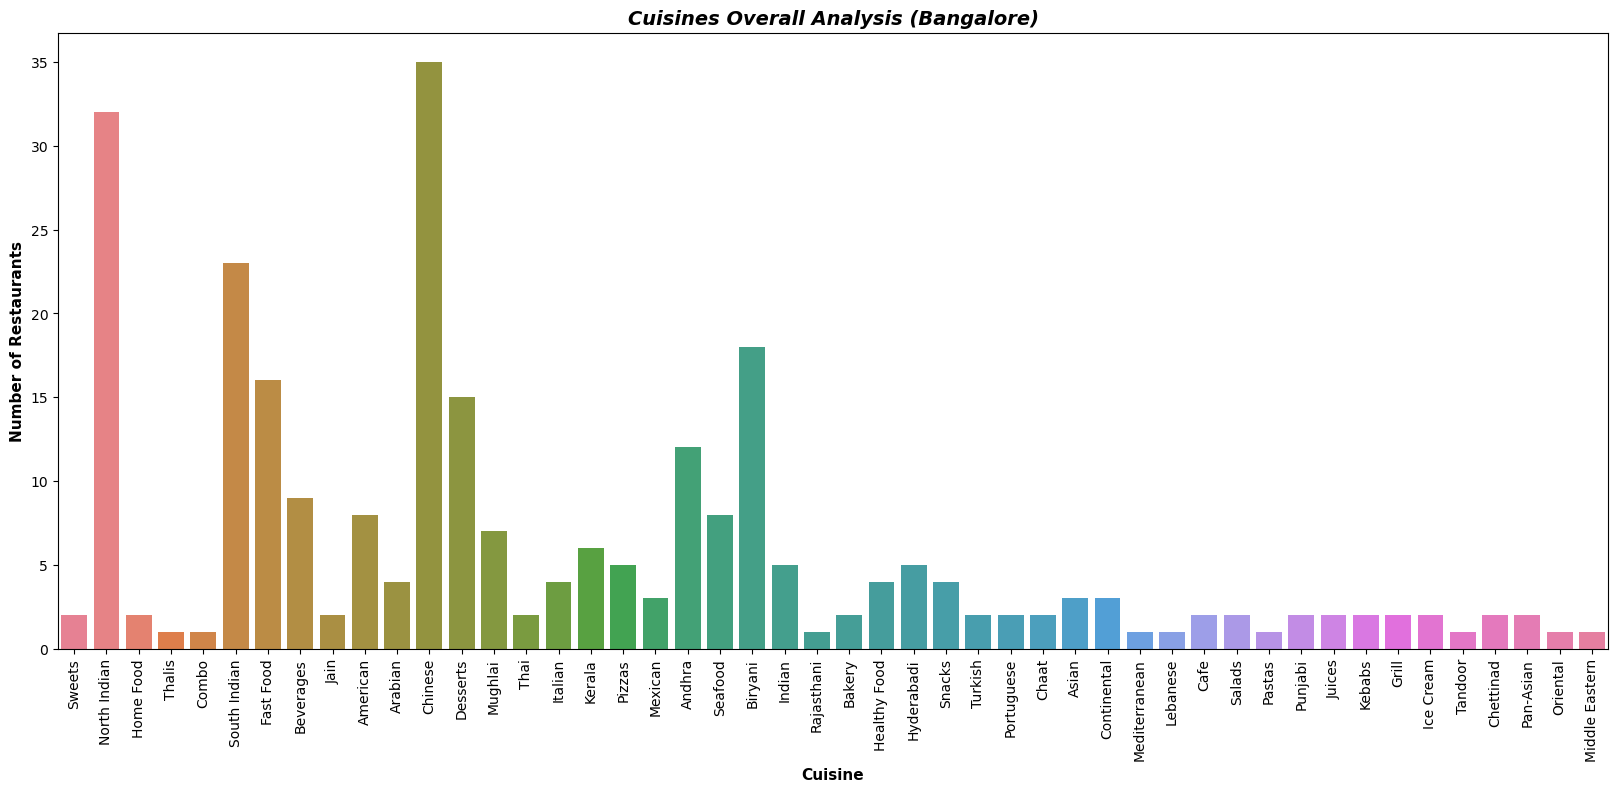

In [93]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine",y="Count",data=df_Cuisine_Analysis,palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisines Overall Analysis (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
)
plt.xlabel("Cuisine", fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurants", fontsize=11, fontweight="bold")
plt.show()

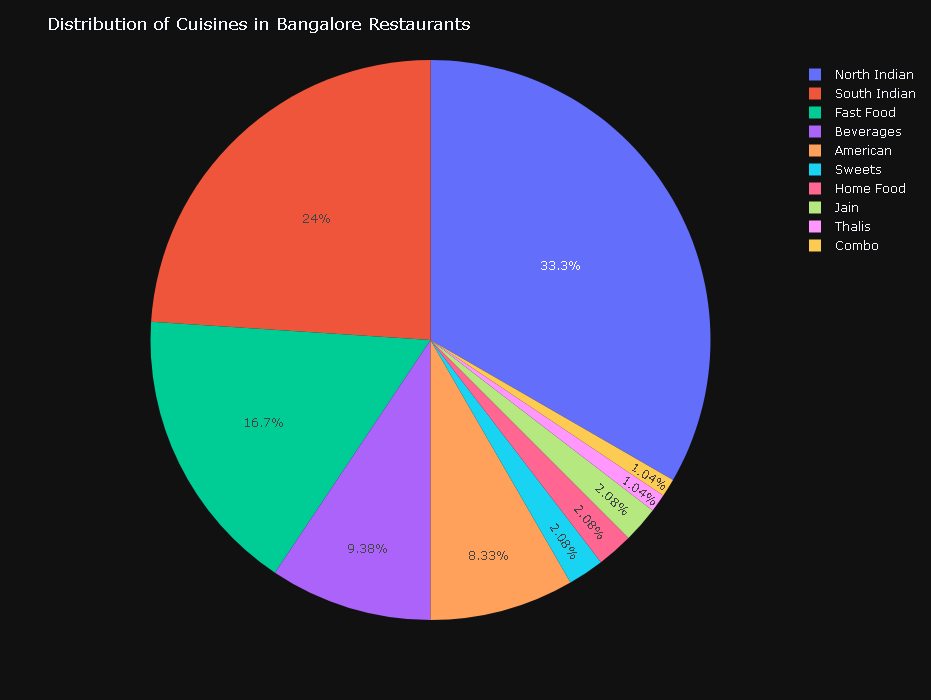

In [94]:
# import plotly.express as px
fig = px.pie(
    data_frame=df_Cuisine_Analysis.head(10),
    names = df_Cuisine_Analysis["Cuisine"][:10],
    values = df_Cuisine_Analysis["Count"][:10],
)
fig. update_layout(
    template="plotly_dark",
    title="Distribution of Cuisines in Bangalore Restaurants",width=700, height=700

)

fig.show()

**Insight:** **Chinese (35 restaurants)** and **North Indian (32)** are the two most commonly offered cuisines across Bangalore, followed by **South Indian (23)**, **Biryani (18)**, and **Fast Food (16)**. This reflects strong demand for pan-Indian and Chinese comfort food over more niche or regional cuisines, most of which appear in only a handful of listings.

## Area-Wise Cuisine Analysis

### BTM Area

In [95]:
swiggy_BTM["Cuisine"].unique()

array(['Fast Food, North Indian, Chinese', 'Italian',
       'Chinese, South Indian, North Indian, Desserts, Fast Food, Kerala, Andhra, Beverages, Mughlai, Seafood',
       'North Indian', 'Desserts, Bakery',
       'North Indian, Chinese, Hyderabadi', 'Indian',
       'Andhra, Biryani, Chinese, Desserts, Fast Food, Seafood, South Indian',
       'Kerala, South Indian', 'North Indian, Chinese, Biryani',
       'Biryani', 'South Indian, Snacks, North Indian, Chinese',
       'Desserts, Fast Food, Sweets, Chaat',
       'Chinese, South Indian, Andhra, Hyderabadi',
       'North Indian, Chinese, South Indian',
       'Biryani, Andhra, South Indian', 'Fast Food, Beverages',
       'Beverages, Chinese', 'Kerala, Chinese', 'North Indian, Chinese',
       'Arabian, Beverages, Biryani, Chinese, Desserts, North Indian',
       'North Indian, South Indian', 'Chinese, Thai',
       'Chinese, Hyderabadi, Biryani, Indian, South Indian, Andhra, Tandoor',
       'Punjabi, North Indian, Chinese, Fast 

In [96]:
freq_BTM = {}
for i in swiggy_BTM["Cuisine"].unique():
    Cuisine_List = i.split(",")
    for Cuisine in Cuisine_List:
        Cuisine = Cuisine.lstrip()
        if Cuisine in freq_BTM:
            freq_BTM[Cuisine] = freq_BTM[Cuisine]+1
        else:
            freq_BTM[Cuisine]=1

print(freq_BTM)
print()
print(len(freq_BTM))


{'Fast Food': 6, 'North Indian': 16, 'Chinese': 18, 'Italian': 1, 'South Indian': 10, 'Desserts': 6, 'Kerala': 4, 'Andhra': 7, 'Beverages': 4, 'Mughlai': 3, 'Seafood': 3, 'Bakery': 1, 'Hyderabadi': 4, 'Indian': 2, 'Biryani': 8, 'Snacks': 1, 'Sweets': 1, 'Chaat': 1, 'Arabian': 2, 'Thai': 1, 'Tandoor': 1, 'Punjabi': 1, 'Healthy Food': 1, 'Chettinad': 1, 'Middle Eastern': 1, 'Grill': 1}

26


In [97]:
Cuisine = freq_BTM.keys()
freq = freq_BTM.values()

dict_BTM = {"Cuisine": Cuisine, "Count": freq}

df_Cuisine_BTM = pd.DataFrame(dict_BTM)
df_Cuisine_BTM.head()

,Cuisine,Count
0,Fast Food,6
1,North Indian,16
2,Chinese,18
3,Italian,1
4,South Indian,10


C:\Users\krish\AppData\Local\Temp\ipykernel_25656\820088214.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




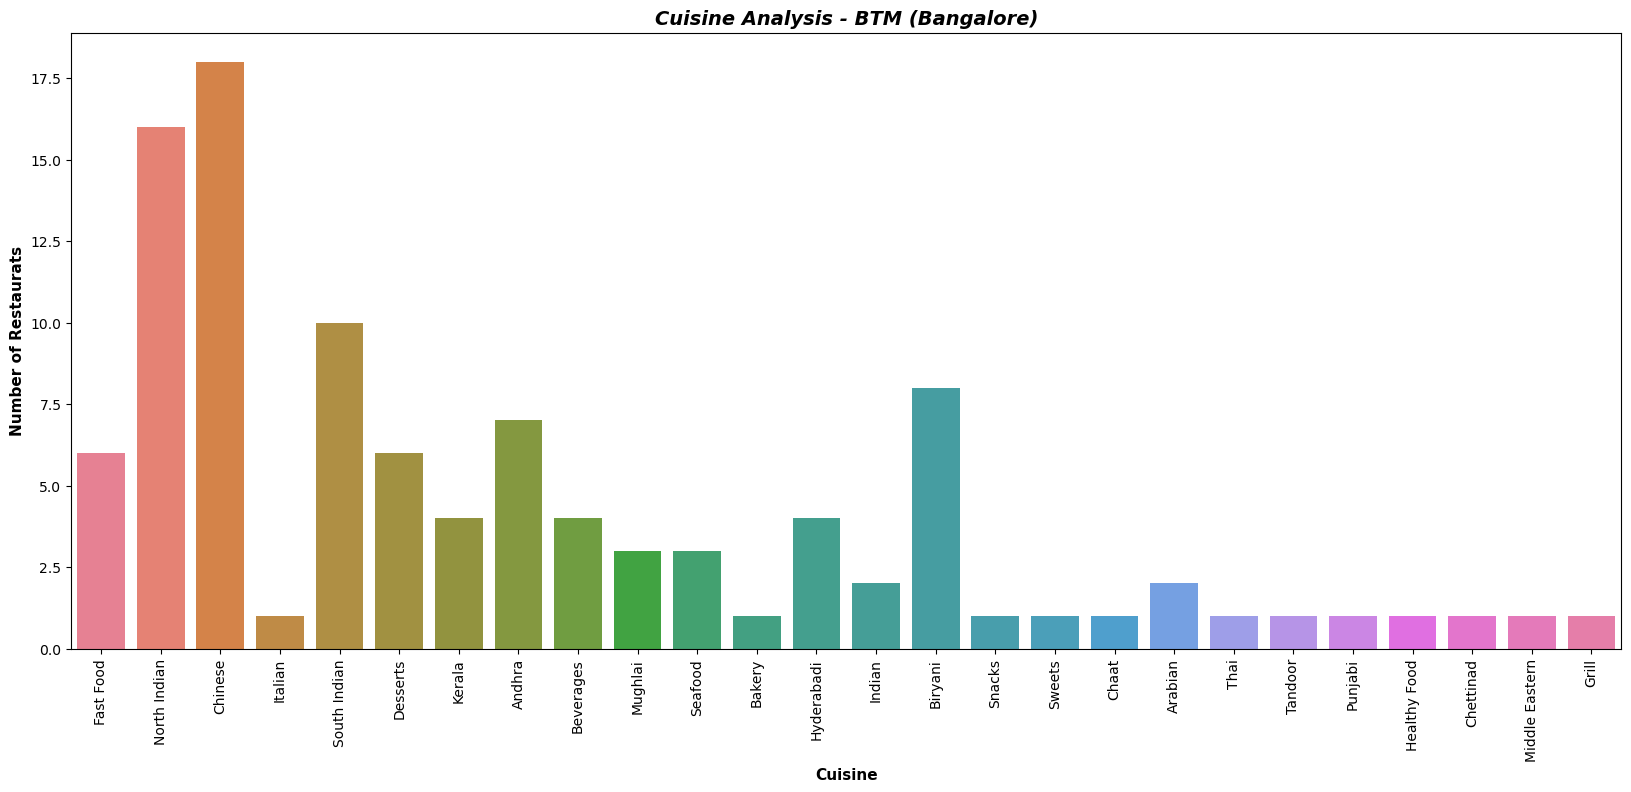

In [98]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine", y="Count", data=df_Cuisine_BTM, palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis - BTM (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
)

plt.xlabel("Cuisine", fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurats", fontsize=11, fontweight="bold")
plt.show()

**Insight** : Chinese (18) and North Indian (16) dominate BTM's cuisine mix by a wide margin, together accounting for over half of all listings. South Indian (10) and Biryani (8) form a clear second tier, while the remaining 20+ cuisines are long-tail — mostly 1-4 restaurants each — showing BTM's menu diversity is real but shallow, concentrated almost entirely in a handful of mainstream cuisines.

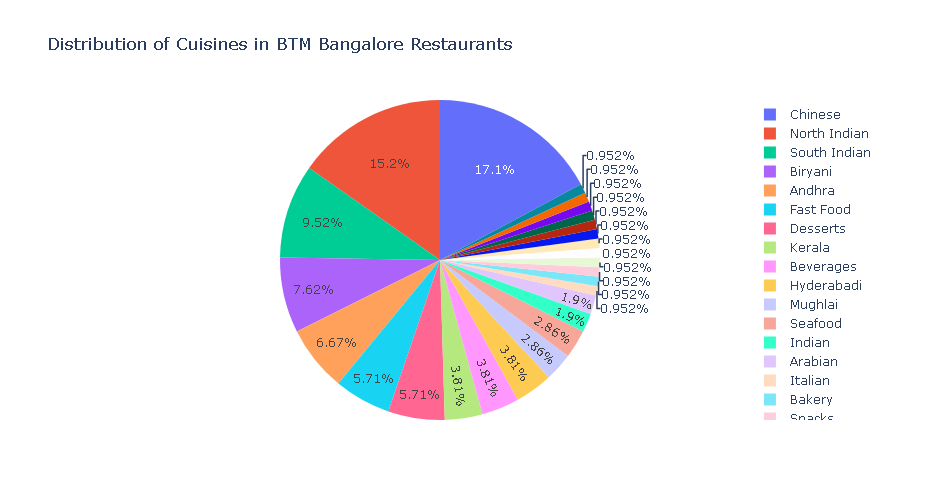

In [99]:
fig= px.pie(
    data_frame=df_Cuisine_BTM,
    names=df_Cuisine_BTM["Cuisine"],
    values=df_Cuisine_BTM["Count"],
    title="Distribution of Cuisines in BTM Bangalore Restaurants", height=500,width=500
)


fig.show()

**Insight:** In BTM, **Chinese (18)** and **North Indian (16)** cuisines dominate, followed by **South Indian (10)** and **Biryani (8)** -- closely mirroring the overall Bangalore-wide cuisine ranking.

### HSR Area

In [100]:
swiggy_HSR["Cuisine"].unique()

array(['North Indian, Home Food, Thalis, Combo',
       'American, Arabian, Chinese, Desserts, Fast Food, Mughlai, North Indian',
       'South Indian, Kerala, Chinese, North Indian',
       'Indian, Rajasthani', 'Chinese, Jain, North Indian, South Indian',
       'North Indian, Chinese, Biryani', 'Turkish, Portuguese, American',
       'Desserts', 'South Indian', 'Andhra, Biryani', 'Desserts, Bakery',
       'Biryani, Juices, Kebabs', 'North Indian', 'Biryani',
       'Snacks, American', 'Chettinad, South Indian'], dtype=object)

In [101]:
freq_HSR = {}
for i in swiggy_HSR["Cuisine"].unique():
    Cuisine_List = i.split(",")
    for Cuisine in Cuisine_List:
        Cuisine = Cuisine.lstrip()
        if Cuisine in freq_HSR:
            freq_HSR[Cuisine] = freq_HSR[Cuisine]+1
        else:
            freq_HSR[Cuisine]=1

print(freq_HSR)
print()
print(len(freq_HSR))

{'North Indian': 6, 'Home Food': 1, 'Thalis': 1, 'Combo': 1, 'American': 3, 'Arabian': 1, 'Chinese': 4, 'Desserts': 3, 'Fast Food': 1, 'Mughlai': 1, 'South Indian': 4, 'Kerala': 1, 'Indian': 1, 'Rajasthani': 1, 'Jain': 1, 'Biryani': 4, 'Turkish': 1, 'Portuguese': 1, 'Andhra': 1, 'Bakery': 1, 'Juices': 1, 'Kebabs': 1, 'Snacks': 1, 'Chettinad': 1}

24


In [102]:
Cuisine = freq_HSR. keys()
freq = freq_HSR. values()

dict_HSR = {"Cuisine": Cuisine, "Count": freq}

df_Cuisine_HSR = pd.DataFrame(dict_HSR)
df_Cuisine_HSR. head()

,Cuisine,Count
0,North Indian,6
1,Home Food,1
2,Thalis,1
3,Combo,1
4,American,3


C:\Users\krish\AppData\Local\Temp\ipykernel_25656\3385114082.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




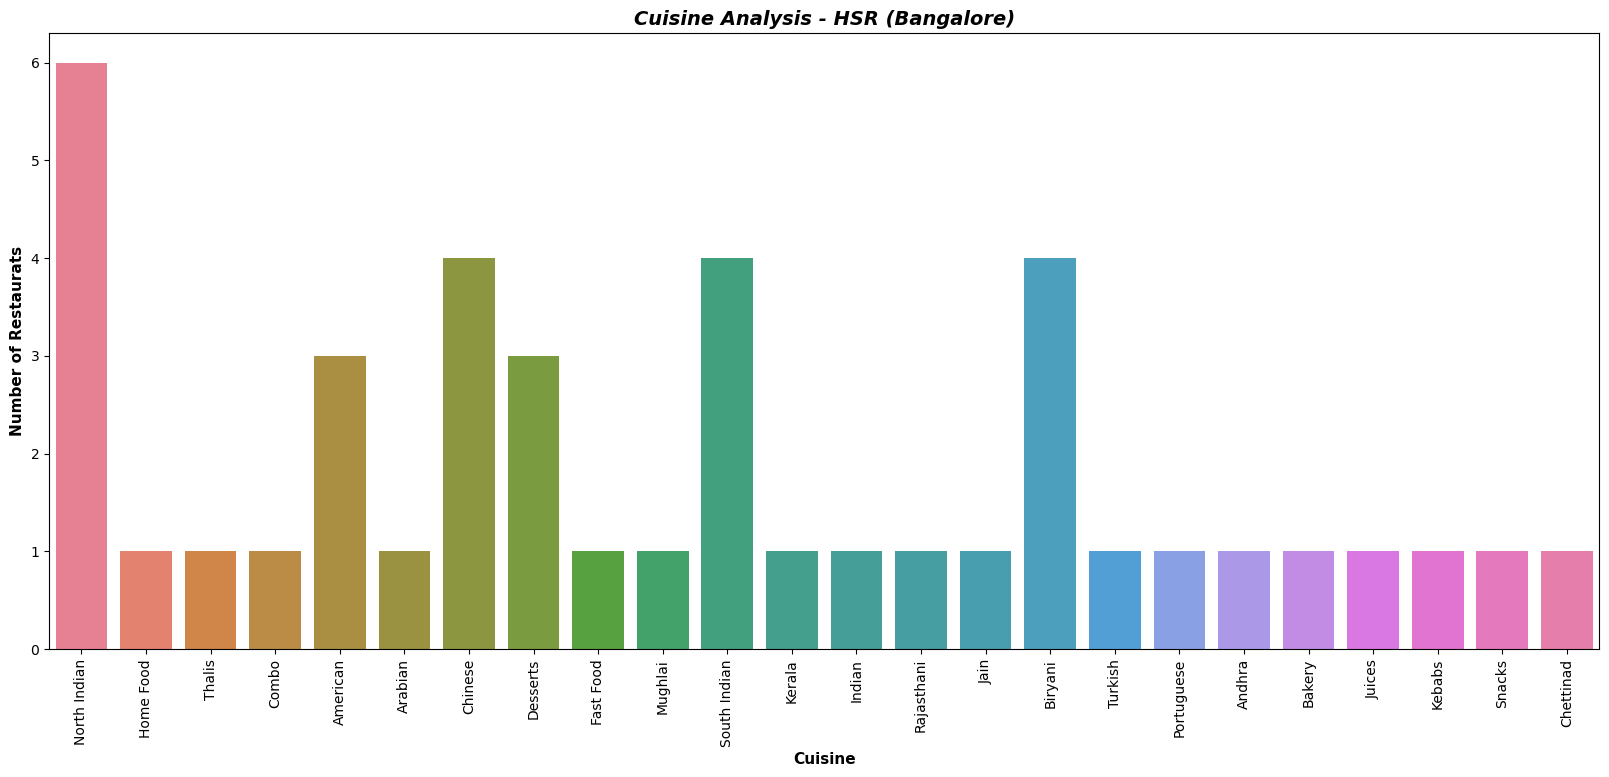

In [103]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine", y="Count", data=df_Cuisine_HSR, palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis - HSR (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
)
plt.xlabel("Cuisine", fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurats", fontsize=11, fontweight="bold")
plt.show()

**Insight**: North Indian (6) leads HSR, but the gap to the rest is much smaller than in BTM — Chinese, South Indian, and Biryani are tied at 4 each. This more even spread, plus 20+ cuisines with just 1 listing, confirms HSR has the most balanced, less mainstream-dominated cuisine mix of the three hubs.

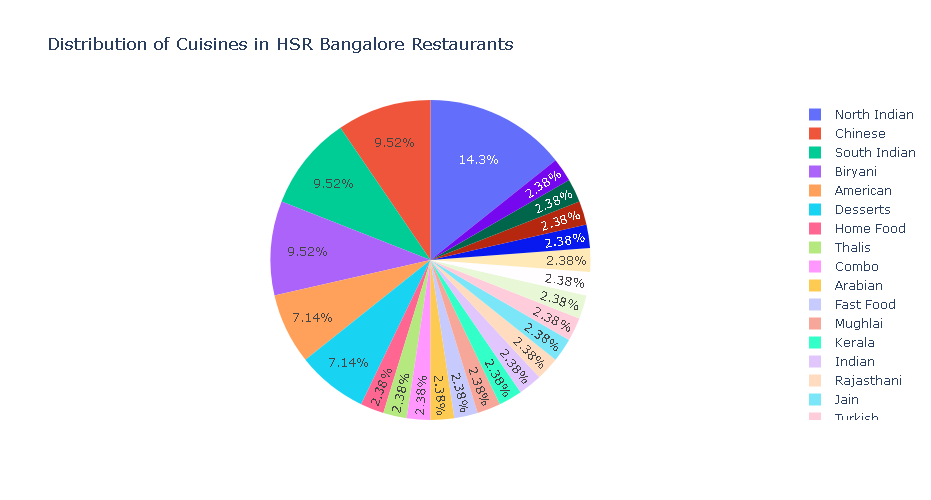

In [104]:
fig= px.pie(
    data_frame=df_Cuisine_HSR,
    names=df_Cuisine_HSR["Cuisine"],
    values=df_Cuisine_HSR["Count"],
    title="Distribution of Cuisines in HSR Bangalore Restaurants", height=500,width=500
)

# fig.updatw_traces(textposition="inside")
fig.show()

**Insight:** HSR shows a more even spread across cuisines, led by **North Indian (6)**, with **Chinese, South Indian, and Biryani tied at 4** each -- suggesting HSR's restaurant scene is more cuisine-diverse relative to its smaller total restaurant count compared to BTM and Koramangala.

### Koramangala Area

In [105]:
freq_Koramangala = {}
for i in swiggy_Koramangala["Cuisine"].unique():
    Cuisine_List = i.split(",")
    for Cuisine in Cuisine_List:
        Cuisine = Cuisine.lstrip()
        if Cuisine in freq_Koramangala:
            freq_Koramangala[Cuisine] = freq_Koramangala[Cuisine]+1
        else:
            freq_Koramangala[Cuisine]=1

print(freq_Koramangala)
print()
print(len(freq_Koramangala))

{'Sweets': 1, 'South Indian': 11, 'North Indian': 14, 'Fast Food': 9, 'Beverages': 5, 'Jain': 1, 'Chinese': 15, 'Thai': 2, 'Pizzas': 5, 'Italian': 4, 'Mexican': 3, 'Desserts': 8, 'Andhra': 5, 'Biryani': 10, 'Seafood': 5, 'Arabian': 1, 'Healthy Food': 3, 'American': 6, 'Snacks': 3, 'Mughlai': 3, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Bakery': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 1, 'Hyderabadi': 1, 'Kerala': 1, 'Turkish': 1, 'Portuguese': 1, 'Grill': 1, 'Home Food': 1, 'Indian': 2, 'Ice Cream': 2, 'Juices': 1, 'Chaat': 1, 'Kebabs': 1, 'Pan-Asian': 2, 'Oriental': 1}

42


In [106]:
Cuisine = freq_Koramangala.keys()
freq = freq_Koramangala.values()

dict_Koramangala = {"Cuisine": Cuisine, "Count": freq}

df_Cuisine_Koramangala = pd.DataFrame(dict_Koramangala)
df_Cuisine_Koramangala.head()

,Cuisine,Count
0,Sweets,1
1,South Indian,11
2,North Indian,14
3,Fast Food,9
4,Beverages,5


C:\Users\krish\AppData\Local\Temp\ipykernel_25656\3614992988.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




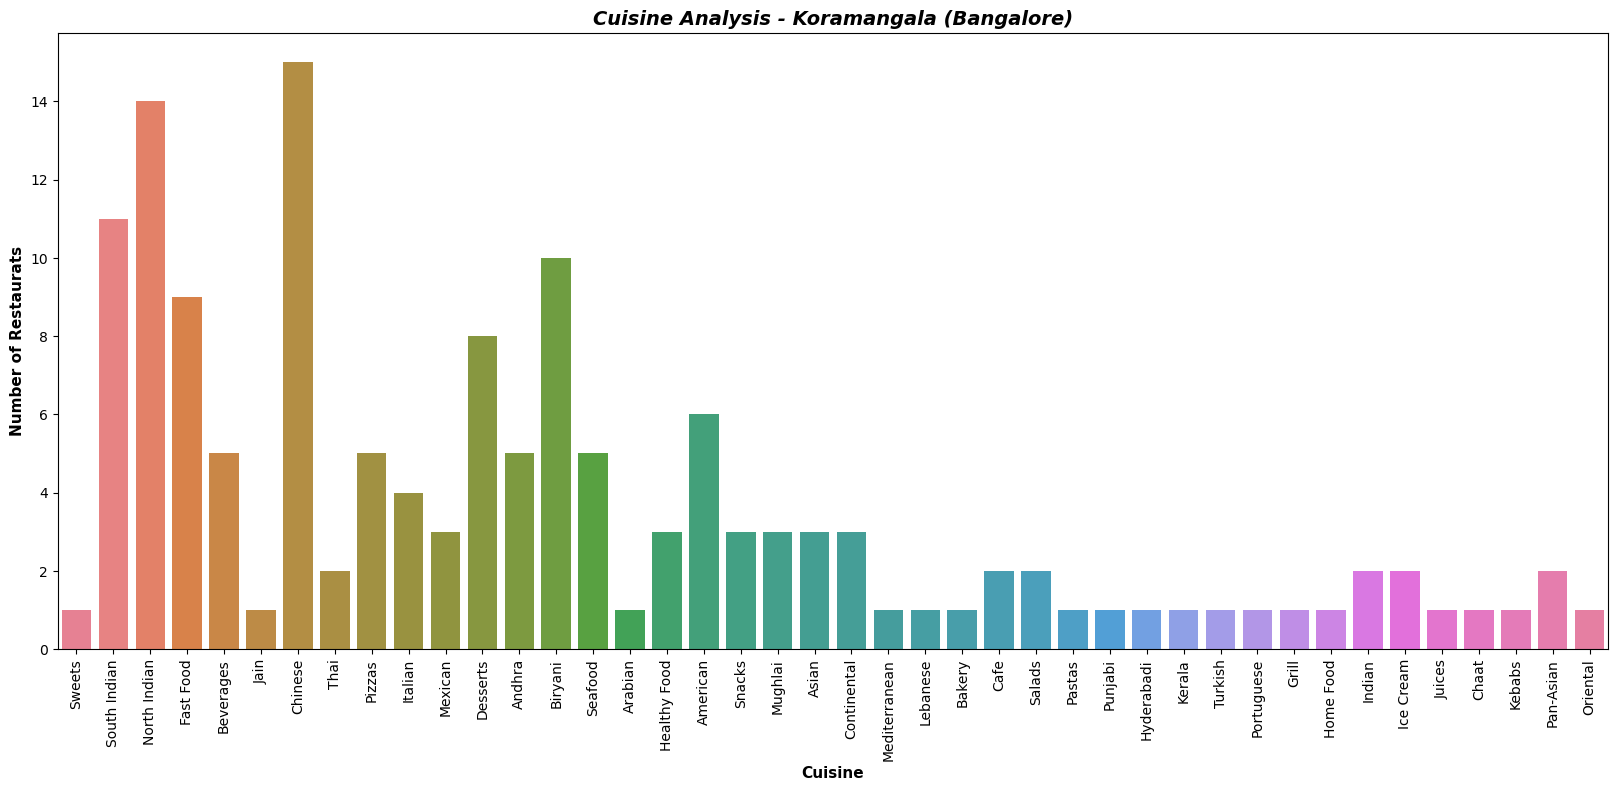

In [107]:
plt.figure(figsize=(20,8))
sns.barplot(x="Cuisine", y="Count", data=df_Cuisine_Koramangala, palette="husl")
plt.xticks(rotation=90)
plt.title(
    "Cuisine Analysis - Koramangala (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
)
plt.xlabel("Cuisine", fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurats", fontsize=11, fontweight="bold")
plt.show()

**Insight**: Chinese (15) and North Indian (14) top Koramangala too, but with a deeper second tier than BTM or HSR — South Indian (11), Biryani (10), Fast Food (9), and Desserts (8) all have meaningful representation. Combined with 30+ cuisines overall, this confirms Koramangala as the most cuisine-diverse hub, not just the busiest.

In [108]:
fig= px.pie(
    data_frame=df_Cuisine_Koramangala,
    names=df_Cuisine_Koramangala["Cuisine"],
    values=df_Cuisine_Koramangala["Count"],
    title="Distribution of Cuisines in Koramangala Bangalore Restaurants", height=500,width=500
)


fig.show()

**Insight:** Koramangala mirrors the city-wide pattern closely, led by **Chinese (15)** and **North Indian (14)**, followed by **South Indian (11)**, **Biryani (10)**, and **Fast Food (9)** -- consistent with Koramangala's reputation as Bangalore's most restaurant-dense, food-diverse neighborhood.

## Key Findings:
- The dataset covers **118 restaurants** across three major Bangalore food hubs: BTM, HSR, and Koramangala, with no missing values or duplicates.
- **BTM and Koramangala** offer similar value -- ratings mostly between 4.0-4.3 with cost for two around ₹200-350.
- **HSR** is slightly pricier (₹300-400 typical) but maintains comparably strong ratings.
- **Cost and rating are only weakly related** -- some of the highest-rated restaurants in the dataset (e.g. Khichdi Experiment at 4.8) cost as little as ₹150-200, while several ₹600-800 restaurants rate no higher than 4.0-4.3.
- The best value-for-money restaurants include **Khichdi Experiment, Natural Ice Cream, and Corner House Ice Cream** -- all rated 4.6+ at ₹250 or less.
- **Chinese and North Indian** are the most commonly offered cuisines city-wide, followed by South Indian, Biryani, and Fast Food -- a pattern that holds fairly consistently across all three areas, with HSR showing slightly more cuisine diversity relative to its size.




## Business Recommendations:
- Since cost doesn't reliably predict rating, marketing/discovery features could highlight "hidden gem" affordable-but-highly-rated restaurants (like the top value list above) to improve customer satisfaction and order value simultaneously.
- Given the strong overlap in top cuisines across all three areas, a delivery platform could use this as a baseline expectation and instead promote under-represented cuisines to increase menu diversity in each hub.
- HSR's smaller, more diverse restaurant base could be an area of focus for restaurant onboarding/expansion given comparatively less concentration around a couple of dominant cuisines.




## Limitations:
- Unrated restaurants were encoded as `Rating = 0` rather than left as null, which could slightly distort any rating-based aggregate statistics (e.g. average rating) if not filtered out beforehand.
- The dataset is a single snapshot in time and does not capture how ratings, pricing, or availability change over time.- Location segmentation relied on substring matching on free-text location strings, which works well for this dataset's three hubs but would need to be generalized (e.g. with a proper location/pincode field) to scale to more areas.



## Future Scope:
- Expand the dataset to cover more Bangalore neighborhoods for a city-wide comparison.
- Combine with order volume/delivery time data (if available) to analyze popularity beyond just ratings.
- Build a simple recommendation feature that surfaces "best value" restaurants per cuisine and area.